In [1]:
from tqdm import tqdm
import os
import joblib
from get_logprobs import LMLogProbs

from feature_extractor import get_features
from feature_extractor import split_sentences_max_words


[nltk_data] Downloading package punkt to /home/udntn/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/udntn/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:

sentence_model = joblib.load("sentence_rf_detector_calibrated-all-data-with-read.joblib", mmap_mode="r")
sentence_scaler = joblib.load("scaler_sentence_rf-all-data-with-read.joblib")

meta_model = joblib.load("meta_classifier-all-data-v11.joblib", mmap_mode="r")
meta_scaler = joblib.load("scaler_meta-all-data-v11.joblib")

/usr/lib/python3.12/contextlib.py:137: UserWarning: mmap_mode "r" is not compatible with compressed file sentence_rf_detector_calibrated-all-data-with-read.joblib. "r" flag will be ignored.
  return next(self.gen)


In [5]:
lm_models = {
    "gpt2": LMLogProbs("gpt2-medium"),
    #"pythia": LMLogProbs("EleutherAI/pythia-410m")
    #"neo": LMLogProbs("EleutherAI/gpt-neo-1.3B")
}

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
import numpy as np
from scipy.stats import entropy
# -----------------------------
# Utility functions
# -----------------------------
def predict_sentence_probs(text_list):
    feats = []
    if len(text_list) == 0:
        return np.array([])

    for item in text_list:
        f = get_features(item["log_prob"], item["sentence"])
        f = np.delete(f, [11, 12, 13, 14, 15, 19, 20, 21])
        feats.append(f)
        
    if len(feats) == 0:
        return np.array([])

    X = np.vstack(feats)
    X_scaled = sentence_scaler.transform(X)
    probs = sentence_model.predict_proba(X_scaled)[:, 1]

    return probs

def meta_predict(meta_features):
    X = np.array(meta_features).reshape(1, -1)     # shape: (n_samples, n_features)
    X_scaled = meta_scaler.transform(X)
    probs = meta_model.predict_proba(X_scaled)[:, 1]
    return probs

def get_chunk_features(sentence_probs, chunk_size=4):
    chunk_feats = []
    for i in range(0, len(sentence_probs), chunk_size):
        chunk = np.array(sentence_probs[i:i+chunk_size])
        chunk_feats.append([
            chunk.mean(),
            chunk.max(),
            chunk.min(),
            chunk.std(),
            np.percentile(chunk, 10),
            np.percentile(chunk, 90),
            np.median(chunk)
        ])
    return np.vstack(chunk_feats)

def prepare_meta_features(texts):
    # sentence-level probabilities
    sentence_probs = predict_sentence_probs(texts)

    

    p = np.array(sentence_probs)

    if len(p) < 3:
        return np.zeros(14)

    # -----------------------------
    # 🔥 CORE DISTRIBUTION FEATURES
    # -----------------------------
    dist_feats = np.array([
        p.mean(),                         # overall confidence
        p.std(),                          # spread
        np.min(p),                        # weakest sentence
        np.percentile(p, 25),             # lower quartile
        np.percentile(p, 75),             # upper quartile
        entropy(p + 1e-8),                # randomness
    ])

    # -----------------------------
    # 🔥 LOW-PROBABILITY MASS (VERY IMPORTANT)
    # -----------------------------
    prop_feats = np.array([
        np.mean(p < 0.05),                # strongest signal
        np.mean(p < 0.1),
        np.mean(p < 0.2),
    ])

    # -----------------------------
    # 🔥 CHUNK EXTREMES (KEY)
    # -----------------------------
    chunk_feats = get_chunk_features(p)

    chunk_min = chunk_feats.min(axis=0)
    

    chunk_selected = np.concatenate([
        [chunk_min[2]],   # ✅ wrap
        [chunk_min[5]],   # ✅ wrap
    ])

    # -----------------------------
    # 🔥 POSITION SIGNAL
    # -----------------------------
    third = len(p) // 3
    if third > 0:
        pos_feats = np.array([
            p[:third].mean(),
            p[-third:].mean(),  # end_mean (important)
        ])
    else:
        pos_feats = np.zeros(2)

    #prop_grad= np.array([
    #    np.mean(np.diff(p)),
    #    np.std(np.diff(p)),
    #    np.max(np.abs(np.diff(p)))
    #])

    low_mask = (p < 0.1).astype(int)
    max_run = max_consecutive_ones(low_mask)/ len(p)

    # -----------------------------
    # FINAL VECTOR
    # -----------------------------
    meta_features = np.concatenate([
        dist_feats,
        prop_feats,
        chunk_selected,
        pos_feats,
        #prop_grad,
        [max_run]   # wrap scalar
    ])

    return meta_features.astype(np.float32)

def max_consecutive_ones(arr):
    max_run = 0
    current_run = 0

    for x in arr:
        if x == 1:
            current_run += 1
            if current_run > max_run:
                max_run = current_run
        else:
            current_run = 0

    return max_run

In [6]:
import pandas as pd
import torch
import json
from tqdm import tqdm
from itertools import chain
import os
from torch import amp

BATCH_SIZE = 16       # Number of sentences per batch
MAX_TOKENS = 1024     # Max tokens per sentence
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
window = 4

for model_name, lm in lm_models.items():
    if lm.tokenizer.pad_token is None:
        lm.tokenizer.pad_token = lm.tokenizer.eos_token
    lm.model.to(DEVICE)
    lm.model.eval()
    lm.model.half()

def get_batch_token_logprobs_and_tokens(lm, texts, max_length=MAX_TOKENS):
    enc = lm.tokenizer(
        texts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length
    ).to(DEVICE)

    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    with torch.no_grad():
        with amp.autocast("cuda"):
            out = lm.model(input_ids=input_ids, attention_mask=attention_mask)
            log_probs = torch.nn.functional.log_softmax(out.logits, dim=-1)
    
            token_logps = log_probs.gather(
                2, input_ids[:, 1:].unsqueeze(-1)
            ).squeeze(-1)

    lengths = attention_mask.sum(dim=1) - 1

    results = []
    for i in range(len(texts)):
        L = lengths[i].item()
        toks = lm.tokenizer.convert_ids_to_tokens(input_ids[i, 1:L+1])
        lps = token_logps[i, :L].cpu().numpy()
        results.append((toks, lps))

    return results

In [7]:
def sentence_probs(text):
    sentences = split_sentences_max_words(text)

    results = []

    for s in sentences:
        if len(s) < 10:
            continue
        tokens_gpt2, log_probs_gpt2 = get_batch_token_logprobs_and_tokens(
            lm_models["gpt2"], [s]
        )[0]
        
        if(len(log_probs_gpt2) < 5):
            continue

        item = {
            "sentence": s,
            "log_prob": log_probs_gpt2
        }

        prob = predict_sentence_probs([item])[0]
        item["prob"] = prob

        results.append(item)

    return results

def chunk_probs(text):
    sentences = split_sentences_max_words(text)

    if len(sentences) <= window:
        chunks = [" ".join(sentences)]
    else:
        chunks = []
        for j in range(0, len(sentences) - window + 1, 1):
            chunks.append(" ".join(sentences[j:j+window]))

    results = []

    for c in chunks:
            
        tokens_gpt2, log_probs_gpt2 = get_batch_token_logprobs_and_tokens(lm_models["gpt2"], [c])[0]
        #tokens_pythia, log_probs_pythia = get_batch_token_logprobs_and_tokens(lm_models["pythia"], [c])[0]  

        feats = get_features(log_probs_gpt2, c)
    
        if feats is None:
            continue

        
        feats = feats.reshape(1, -1)   # 🔑 REQUIRED

        #Xc = scaler_chunk.transform(feats)
        #prob = chunk_model.predict_proba(Xc)[0, 1]
#
        #print("Chunk feats:", combined)
        #print("Any NaN:", np.isnan(combined).any())
        #print("Std:", np.std(combined))

        results.append({
            "chunk": c,
            "prob": float(prob),
            "length": len(c.split())
        })

    return results

def predict_essay(text):
    sent_results = sentence_probs(text)


    meta_features = prepare_meta_features(sent_results)
    meta_results = meta_predict(meta_features)

    return {
        "sentence_results": sent_results,
        "meta_results": meta_results
        #"chunks": chunk_results
    }

In [ ]:


# -----------------------------
# Load models and scalers
# -----------------------------


# -----------------------------
# Parameters
# -----------------------------
SENT_THRESHOLD = 0.39
CHUNK_THRESHOLD = 0.43

W_SENT = 0.4   # weight for sentence model
W_CHUNK = 0.6  # weight for chunk model

# -----------------------------
# Essay-level prediction
# -----------------------------

# -----------------------------
# Example usage
# -----------------------------
while True:
    text = input("\nPaste an essay (or 'quit'): ")
    if text.strip().lower() == "quit":
        break

    result = predict_essay(text)  

    print("\n--- Sentence probabilities ---")
    for r in result["sentence_results"]:
        print(f"{r['prob']:.3f} | {r['sentence']}")

    
    
    print("\n--- meta probabilities ---")
    print(result["meta_results"])
    #essay_prob = np.average(sent_probs, weights=[r['length'] for r in result['sentences']])
    #print(f"Essay-level AI probability: {sent_probs :.3f}")

    
    #print("Combined prob:", result["combined_prob"])
    #print("Prediction:", result["prediction"])

In [ ]:
from datasets import load_dataset

ds = load_dataset("artem9k/ai-text-detection-pile")

print(type(ds))
print(ds)

texts  = ds["text"]
labels = np.array(ds["label"])

# Run your detector
pred_probs = np.array([predict_essay(t) for t in texts])
pred_labels = (pred_probs > 0.5).astype(int)

# RAID evaluation

print(metrics)

<class 'pandas.core.frame.DataFrame'>
                                          id  \
0       64005577-3d63-4583-8945-7541d3e53e7d   
1       c2b9df67-4e29-45ca-bdcc-7065fb907b77   
2       07904f22-8530-4d3b-bf49-6bd1642d89f7   
3       dc5aa023-6f57-4f9c-833a-c0f322a994fa   
4       1b1ab19b-fe6f-458d-a666-06bbc1791534   
...                                      ...   
671995  b2694dd7-1c4d-4bef-8e52-0c1e13d54130   
671996  9e5c1a37-9305-4ca7-8dc0-ab1ed763231e   
671997  a233aa5d-b375-423f-ad7a-ffc5045398c5   
671998  e267ebb4-b1f7-4af4-b68b-ecd4ba565f93   
671999  45df9738-b31c-495b-9a0d-2c62220df990   

                                               generation  
0         The Sunspot Number, created by R.Wolf in 184...  
1         We present several analogies between convex ...  
2         Let H be a homology theory for algebraic var...  
3         The two parallel concepts of "small" sets of...  
4         We present new solutions to the strong explo...  
...                      

KeyError: 'label'

In [23]:
from datasets import load_dataset
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------------
# Load dataset and create balanced subset
# -----------------------------
ds = load_dataset("artem9k/ai-text-detection-pile", split="train")

# Separate classes
human_idx = [i for i, s in enumerate(ds["source"]) if s == "human"]
ai_idx    = [i for i, s in enumerate(ds["source"]) if s == "ai"]

# Pick equal number from both
n_samples = 1000
np.random.seed(42)
human_idx = np.random.choice(human_idx, n_samples, replace=False)
ai_idx    = np.random.choice(ai_idx, n_samples, replace=False)

# Combine and shuffle
balanced_idx = np.concatenate([human_idx, ai_idx])
np.random.shuffle(balanced_idx)
balanced_ds = ds.select(balanced_idx)

# Extract texts and labels
texts = balanced_ds["text"]
labels = np.array([0 if s == "human" else 1 for s in balanced_ds["source"]])

pred_probs = []
pred_labels = []
# Run your detector
all_results = []

for text in tqdm(texts, total=len(texts)):
    result = predict_essay(text)
    all_results.append(result)  # keep the full dict
    essay_prob = result["meta_results"][0]
    pred_probs.append(essay_prob)

# Now pred_probs = floats
# all_results = raw dicts

100%|██████████| 2000/2000 [1:23:34<00:00,  2.51s/it]


[0.021192858901600622, 0.8304847187142713, 0.8096750833847297, 0.005558630320955914, 0.0013536690938730658, 0.0009984584685489267, 0.42108836713793374, 0.5644283292477029, 0.0016407111541461579, 0.4791515897797969, 0.9996953077391835, 0.05358206299644402, 0.0009984584685489267, 0.004109846956615293, 0.9355626659187674, 0.007437293389161908, 0.9695447811732901, 0.0009984584685489267, 0.8591796888725817, 0.5300034806094951, 0.0016407111541461579, 0.31482469389290824, 0.008422333801943347, 0.5644283292477029, 0.0009984584685489267, 0.029401798340810584, 0.008984114247272142, 0.0, 0.03554274364133519, 0.9992300460577407, 0.8304847187142713, 0.9588083674416152, 0.5644283292477029, 0.024220272887918715, 0.021192858901600622, 0.379390467747885, 0.9203553662789666, 0.0013536690938730658, 0.010053277855135441, 0.6328598243705196, 0.252005826349264, 0.0009984584685489267, 0.027717377325402835, 0.9764775359646795, 0.11447850115975423, 0.9643517432211525, 0.004412437128486511, 0.047463020295837634

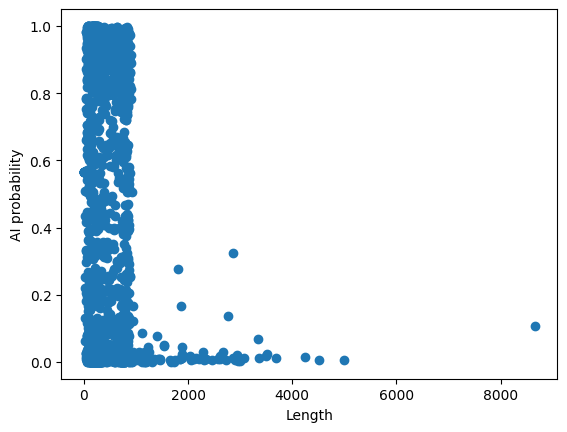

In [26]:
#out = predict_essay(texts[0])
print(pred_probs)
#print(type(out))

pred_labels = (np.array(pred_probs) > 0.4).astype(int)

# Metrics
print(classification_report(labels, pred_labels))
print("ROC AUC:", roc_auc_score(labels, pred_probs))

# Length bias plot
lengths = [len(t.split()) for t in texts]
plt.scatter(lengths, pred_probs)
plt.xlabel("Length")
plt.ylabel("AI probability")
plt.show()
